# `find_and_suppress` on MIDOG++ -- simplest-configuration run

**Purpose.** [`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb) ran the
12-angle x 2-flip, `gray_inverted`, single-scale configuration. This notebook strips the
pipeline down further, to the fewest moving parts it can run with:

- **no augmentation** -- one template per seed, angle 0, no flip
- **no multi-scale** -- one template size (the tightened box's own native size)
- **raw RGB template** -- no grayscale conversion, no inversion; the match runs directly
  on the 3-channel crop
- **binary Otsu for bbox tightening** -- `seed_selection.tighten_box_otsu`'s default. The
  multi-otsu comparison in `Research Logs/design_choices.md` section 7 is a separate,
  still-open piece of work; this notebook does not touch it and does not pass
  `bbox_method="multiotsu"` anywhere.

Same seven ROIs (one per tumour domain) as the first run, one pathologist-agreement seed
each, a single forward pass. All logic lives in [`midog_utils/`](midog_utils/); this
notebook only calls it.

**What's actually different from `FSConfig()`'s own defaults.** `n_angles=1`,
`flips=(False,)`, and `scales=(1.0,)` are already the pipeline defaults as of
`Research Logs/design_choices.md` section 6 -- "no augmentation, no multi-scale" needs no
override. The one substantive change below is `channel='rgb'`, replacing the default
`'gray_inverted'`.

**Environment.** `requirements-midog-utils.txt` (numpy < 2, pinned opencv/tifffile) --
verified against this repo's Python 3.11.5 / numpy 1.26.4 / opencv 4.8.1 install.

In [1]:
import sys, time
sys.path.insert(0, '..') if 'midog_utils' not in __import__('os').listdir('.') else None

import numpy as np, pandas as pd, matplotlib.pyplot as plt

from midog_utils import dataset as ds, channels as ch, template_match as tm
from midog_utils import find_and_suppress as fs, evaluate as ev, experiment as ex, viz

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

images, annotations = ds.load_annotations('databases/MIDOG++.json')
ds.check_invariants(annotations)          # every bbox is 50x50 and TLBR, or this raises
print(f'{len(images)} annotated images, {len(annotations)} annotations')

503 annotated images, 26286 annotations


## Which images

Same rule as the first run: one ROI per tumour domain, the downloaded image with the most
mitotic figures (ties to the lower id). See
[`find_and_suppress_midog.ipynb`](find_and_suppress_midog.ipynb) for why this is an
optimistic selection rather than a representative one -- unchanged here, since the point
of this notebook is the matching configuration, not the image-selection rule.

In [2]:
selection = ex.select_domain_images(images, annotations)
selection[['image_id', 'file_name', 'tumor_type', 'n_mitotic']]

,image_id,file_name,tumor_type,n_mitotic
0,301,301.tiff,canine cutaneous mast cell tumor,218
1,201,201.tiff,canine lung cancer,18
2,246,246.tiff,canine lymphosarcoma,116
3,405,405.tiff,canine soft tissue sarcoma,14
4,2,002.tiff,human breast cancer,9
5,506,506.tiff,human melanoma,12
6,350,350.tiff,human neuroendocrine tumor,4


## Configuration

`channel='rgb'` is the only override. Everything else -- one template, angle 0, no flip,
single scale, `score_threshold=0.5` -- is `FSConfig`'s own default. `bbox_method` is left
at `run_one_image`'s default (`"binary"`) throughout; the multi-otsu variant is a separate,
still-open comparison this notebook does not run.

In [3]:
cfg = fs.FSConfig(channel='rgb')
print(cfg)
print(f'\n{cfg.n_augmentations} augmentation(s) per run '
      f'({cfg.n_angles} rotation x {len(cfg.flips)} flip x {len(cfg.scales)} scale) -- '
      'the template is the tightened annotation box itself, untransformed.')

FSConfig(channel='rgb', base_size=51, patch_size=73, scales=(1.0,), n_angles=1, flips=(False,), peak_min_distance=7, score_threshold=0.5, max_peaks=250000, nms_radius=None, self_hit_radius=5.0, max_detections=1000000000, scale_normalize=False)

1 augmentation(s) per run (1 rotation x 1 flip x 1 scale) -- the template is the tightened annotation box itself, untransformed.


## Run

One raw-RGB correlation per image (no augmentation bank to build or fuse), plus the
nucleus-blob and random-in-tissue baselines for context. Much cheaper than the 24-template
run: a single-image smoke test with baselines ran in ~20s, so all seven should take a few
minutes.

In [4]:
t0 = time.time()
results, metrics, detections = ex.run_experiment(selection, annotations, cfg=cfg, seed=0)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics.to_csv('results/fs_simple_metrics.csv', index=False)
detections.to_csv('results/fs_simple_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.304  attraction@K=0.138  coverage=0.84  (26s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.118  attraction@K=0.041  coverage=0.01  (27s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.091  attraction@K=0.000  coverage=0.17  (72s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.16  (37s)



total 257s


## Results

### Headline: `recall@K`

`K` = the number of mitotic figures in that ROI, minus the seed -- see the first
notebook's discussion of why this is the threshold-free headline number. Read
`coverage_frac` alongside it: at `score_threshold=0.5` the detection list is much shorter
than the first run's 0.25-floor lists, so coverage saturation is less of a confound here,
but it is still worth checking per image rather than assumed away.

In [5]:
ex.summary_table(metrics)

,tumor_type,file_name,method,n_gt_mitotic_eval,n_lookalike_gt,recall_at_k,lookalike_attraction_at_k,topk_tp,topk_fp_lookalike,topk_fp_unannotated,sens@8fp_mm2,sens@64fp_mm2,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k,max_detection_score,n_detections_total
0,canine cutaneous mast cell tumor,301.tiff,find_and_suppress,217,109,0.304147,0.137615,66,15,136,0.119816,0.267281,163,0.355828,54,0.148148,0.904356,13353
1,canine lung cancer,201.tiff,find_and_suppress,17,49,0.117647,0.040816,2,2,13,0.117647,0.176471,6,0.000000,11,0.181818,0.635876,127
2,canine lymphosarcoma,246.tiff,find_and_suppress,115,123,0.017391,0.000000,2,0,3,0.017391,0.017391,99,0.020202,16,0.000000,0.598671,5
3,canine soft tissue sarcoma,405.tiff,find_and_suppress,13,19,0.000000,0.000000,0,0,13,0.000000,0.307692,9,0.000000,4,0.000000,0.828673,4479
4,human breast cancer,002.tiff,find_and_suppress,8,7,0.250000,0.000000,2,0,6,0.250000,0.250000,6,0.333333,2,0.000000,0.808039,3621
5,human melanoma,506.tiff,find_and_suppress,11,12,0.090909,0.000000,1,0,10,0.090909,0.090909,7,0.142857,4,0.000000,0.735554,2067
6,human neuroendocrine tumor,350.tiff,find_and_suppress,3,16,0.000000,0.000000,0,0,3,0.000000,0.000000,0,NaN,3,0.000000,0.777925,1940


### Against the baselines

`nucleus_blobs` (any dark blob, hematoxylin channel) and `random_in_tissue` (the floor).
If raw-RGB, single-template matching does not beat the blob detector at an equal budget,
that is the finding for this configuration.

In [6]:
pivot = metrics.pivot_table(index=['tumor_type', 'file_name'], columns='method',
                            values='recall_at_k').round(3)
pivot['lift_vs_blobs'] = (pivot['find_and_suppress'] /
                          pivot['nucleus_blobs'].replace(0, np.nan)).round(2)
pivot

,method,find_and_suppress,nucleus_blobs,random_in_tissue,lift_vs_blobs
tumor_type,file_name,,,,
canine cutaneous mast cell tumor,301.tiff,0.304,0.594,0.0,0.51
canine lung cancer,201.tiff,0.118,0.235,0.0,0.50
canine lymphosarcoma,246.tiff,0.017,0.330,0.0,0.05
canine soft tissue sarcoma,405.tiff,0.000,0.000,0.0,NaN
human breast cancer,002.tiff,0.250,0.000,0.0,NaN
human melanoma,506.tiff,0.091,0.000,0.0,NaN
human neuroendocrine tumor,350.tiff,0.000,0.000,0.0,NaN


### Every detection, not just the top K

Bucketed by what it landed on, with no top-K budget. `coverage_frac` first, as always --
see `evaluate.py`'s module docstring for why a saturated list makes full-list recall
uninformative.

In [7]:
ex.full_list_table(metrics)

,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,canine cutaneous mast cell tumor,301.tiff,13353,0.8357,206,100,13047,306,0.022916,0.015427,206,11,100,9
1,canine lung cancer,201.tiff,127,0.0111,3,3,121,6,0.047244,0.023622,3,14,3,46
2,canine lymphosarcoma,246.tiff,5,0.0005,2,0,3,2,0.400000,0.400000,2,113,0,123
3,canine soft tissue sarcoma,405.tiff,4479,0.3723,13,15,4451,28,0.006251,0.002902,13,0,15,4
4,human breast cancer,002.tiff,3621,0.2893,7,6,3608,13,0.003590,0.001933,7,1,6,1
5,human melanoma,506.tiff,2067,0.1683,5,4,2058,9,0.004354,0.002419,5,6,4,8
6,human neuroendocrine tumor,350.tiff,1940,0.1605,1,7,1932,8,0.004124,0.000515,1,2,7,9


### Expert-agreement split

Mitotic recall split by whether every rater who saw the annotation called it mitotic,
budgeted at the same K as everything else.

In [8]:
metrics[metrics.method == 'find_and_suppress'][
    ['tumor_type', 'file_name', 'k', 'tightened_base_size', 'seed_agreement_flagged',
     'n_unanimous', 'recall_unanimous_at_k', 'n_contested', 'recall_contested_at_k']
].sort_values('tumor_type').reset_index(drop=True)

,tumor_type,file_name,k,tightened_base_size,seed_agreement_flagged,n_unanimous,recall_unanimous_at_k,n_contested,recall_contested_at_k
0,canine cutaneous mast cell tumor,301.tiff,217,35.0,False,163,0.355828,54,0.148148
1,canine lung cancer,201.tiff,17,51.0,False,6,0.000000,11,0.181818
2,canine lymphosarcoma,246.tiff,115,51.0,False,99,0.020202,16,0.000000
3,canine soft tissue sarcoma,405.tiff,13,51.0,False,9,0.000000,4,0.000000
4,human breast cancer,002.tiff,8,35.0,False,6,0.333333,2,0.000000
5,human melanoma,506.tiff,11,43.0,False,7,0.142857,4,0.000000
6,human neuroendocrine tumor,350.tiff,3,41.0,True,0,NaN,3,0.000000


### FROC

Sensitivity against false positives per mm^2, this configuration only (no baseline
overlay -- see the pivot table above for the equal-budget baseline comparison).

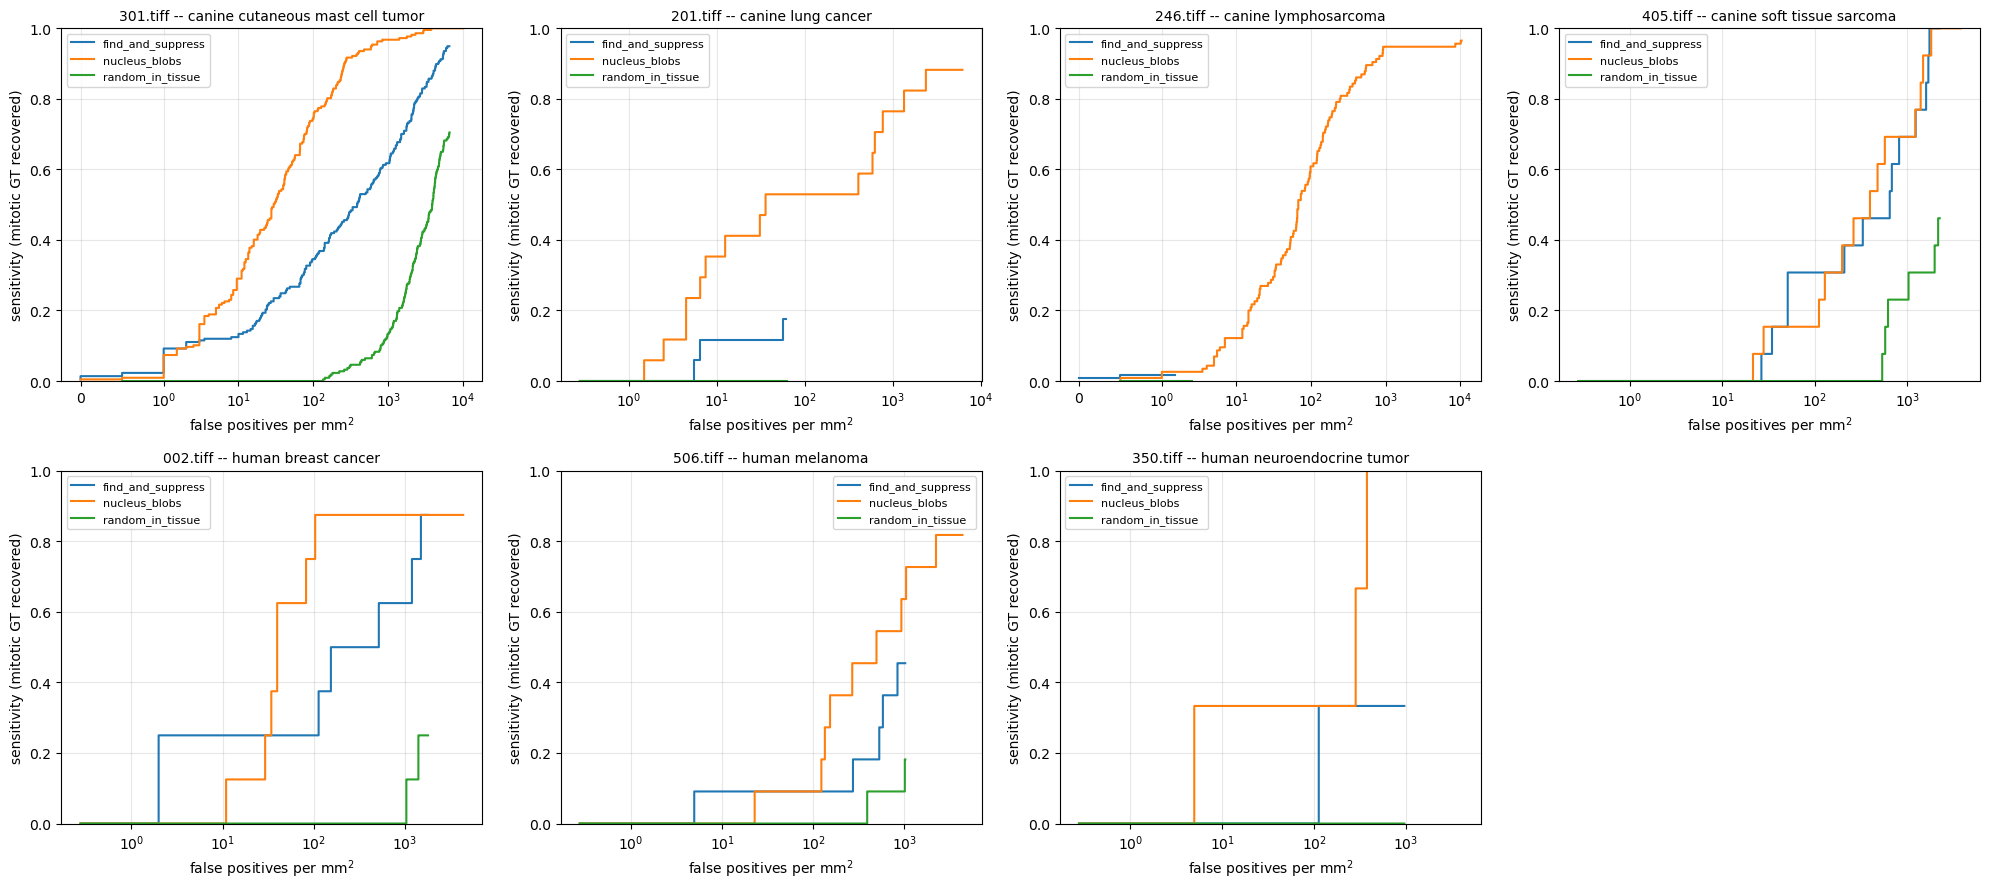

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    curves = [('find_and_suppress', *res['curve'])]
    if 'baseline_blobs_curve' in res:
        curves.append(('nucleus_blobs', *res['baseline_blobs_curve']))
        curves.append(('random_in_tissue', *res['baseline_random_curve']))
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()

### Where the detections land

White star = the seed. Red = ground-truth mitotic figures, yellow = ground-truth
look-alikes. Detections are the top-K only, coloured by bucket, drawn at the match
radius.

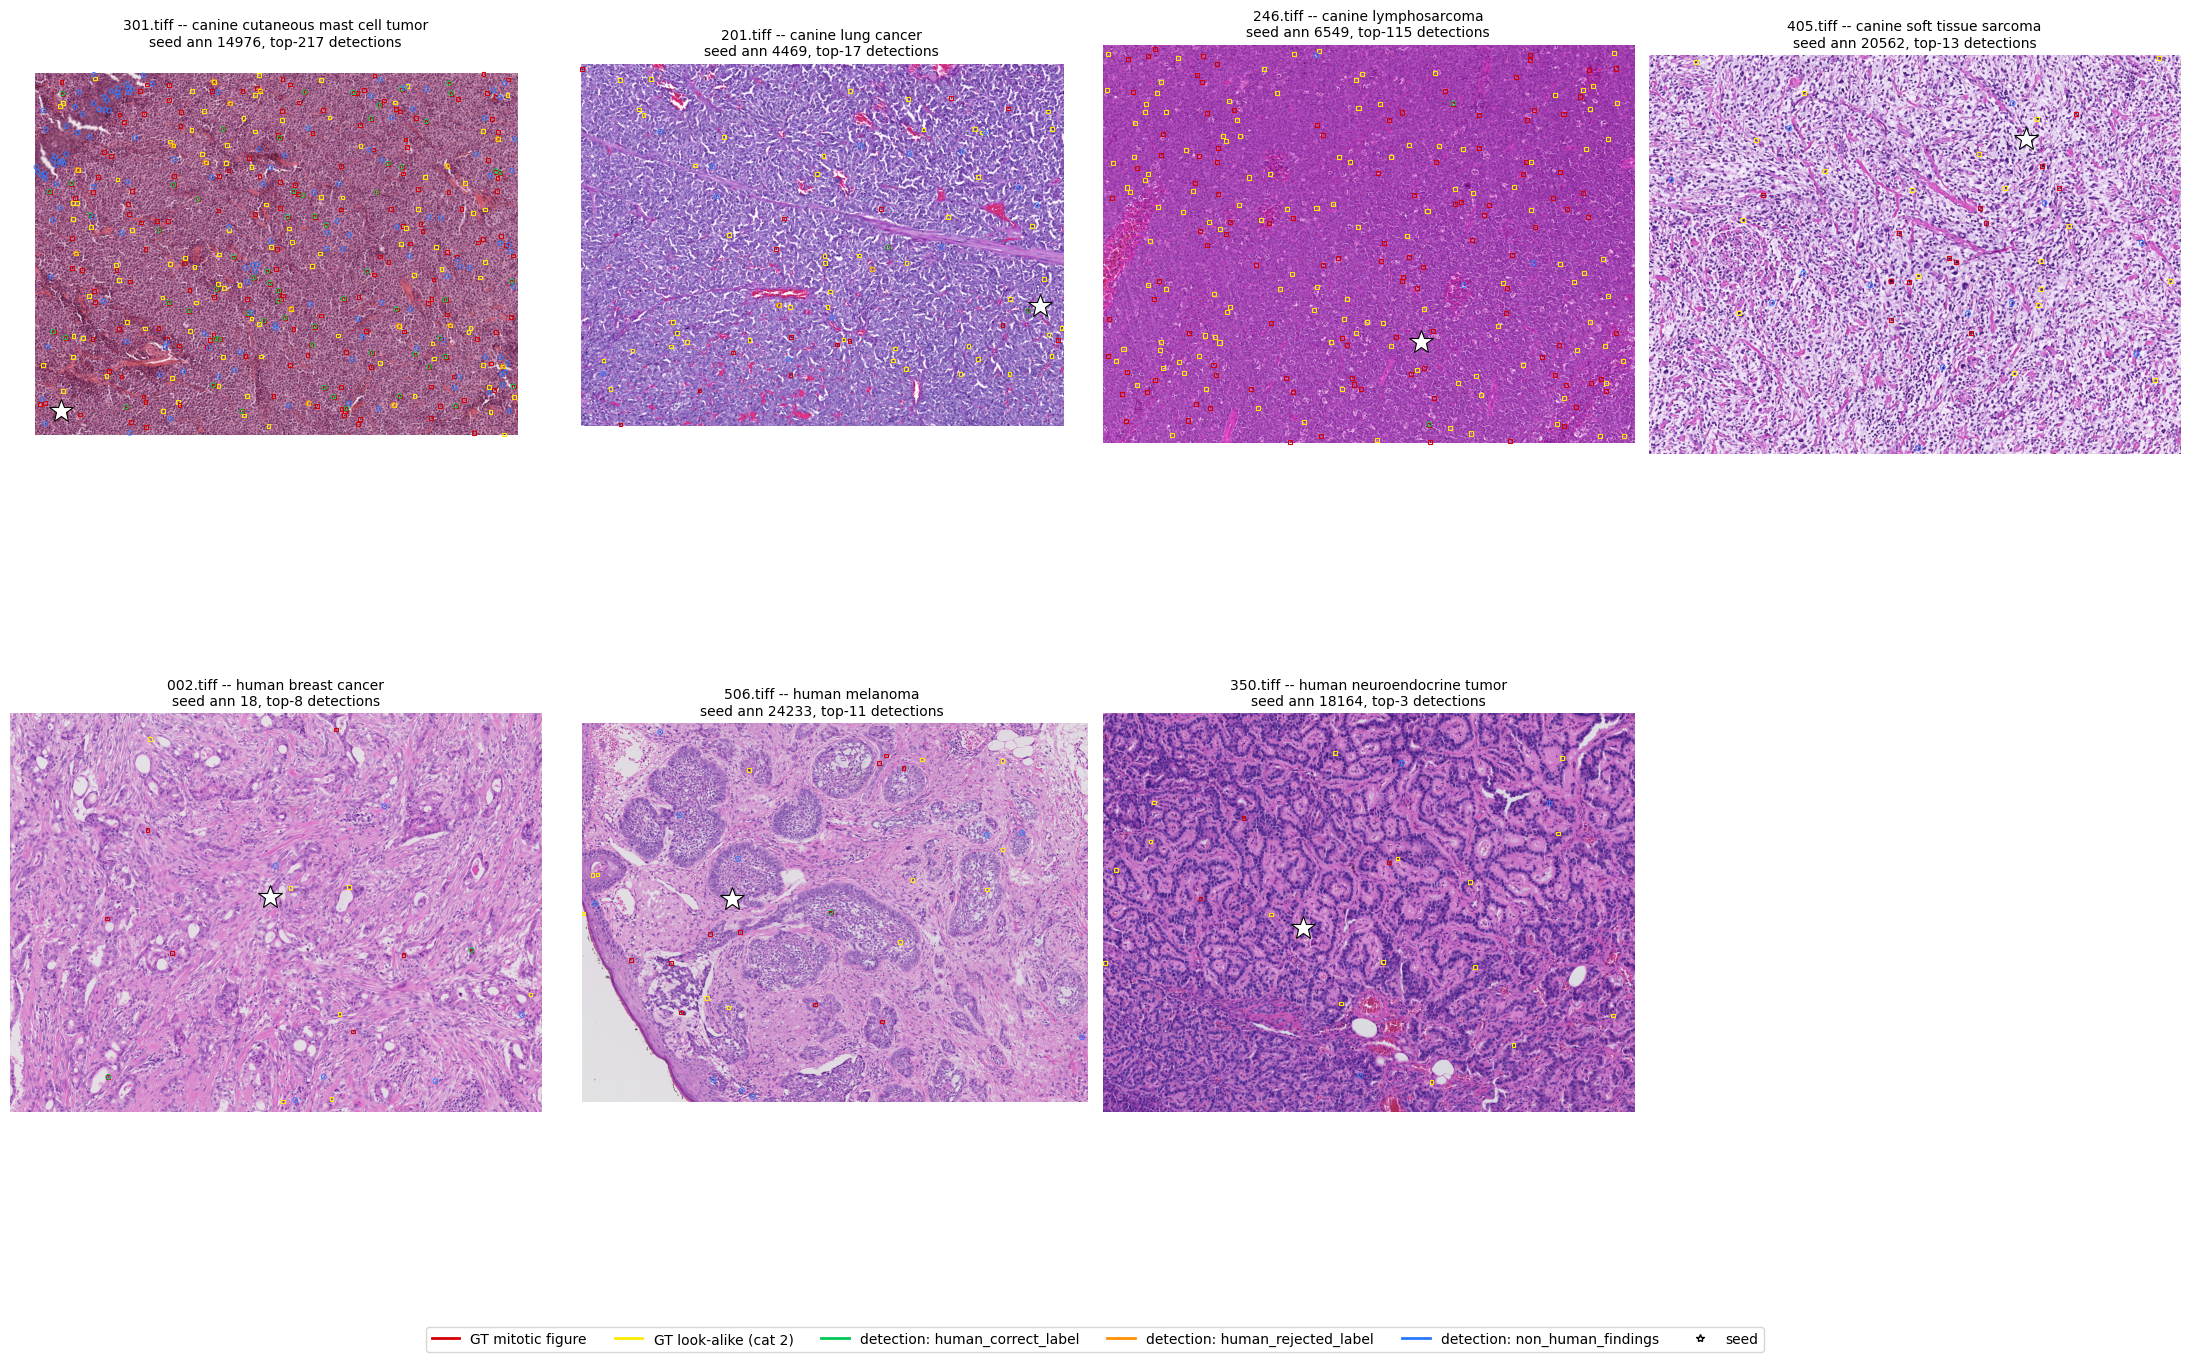

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 15))
for ax, (fn, res) in zip(axes.ravel(), results.items()):
    rgb = ds.load_roi(f'images/{fn}')
    k = res['metrics'][0]['k']
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.overlay(rgb, res['gt'], res['detections'], (res['seed'].cx, res['seed'].cy),
                ax=ax, downsample=4, top_n=k, radius=res['radius'],
                title=f"{fn} -- {tumor}\nseed ann {int(res['seed'].ann_id)}, top-{k} detections")
    del rgb
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.legend(handles=viz.legend_handles(), loc='lower center', ncol=6, fontsize=10)
fig.tight_layout(rect=(0, 0.03, 1, 1)); plt.show()

## Channel comparison: hematoxylin and the original `gray_inverted`

Same simplified pipeline -- one template, no augmentation, no multi-scale, binary Otsu
bbox tightening -- run twice more, changing only `FSConfig.channel`: `hematoxylin`
(colour-deconvolved, chromatin-selective) and `gray_inverted` (`255 - grayscale`, the
channel the *first* notebook used with its 24-template augmentation bank).

**Why this is a clean channel-only ablation, not confounded by a different seed or
template size per run.** `experiment.run_experiment` builds each image's RNG from
`(seed, image_id)` alone, and *seed selection itself* -- `seed_selection.pick_seed` and
`tightened_base_size` -- always runs on the `gray_inverted` structural channel
regardless of `FSConfig.channel` (`experiment.py`'s own docstring: "independent of
`cfg.channel` -- it is a test of where the click sits, not a matching score"). So calling
`run_experiment(..., seed=0)` again with only `channel` changed reproduces the exact same
seed annotation and the exact same tightened template size per image as the RGB run
above -- confirmed below rather than assumed. Only the pixels the correlation itself
reads change.

**Baselines are not re-run.** `nucleus_blobs` and `random_in_tissue` don't depend on
`FSConfig.channel` at all (`nucleus_blobs` converts its own hematoxylin channel from
`rgb` directly, never through `cfg`) -- rerunning them here would reproduce the RGB run's
baseline rows exactly, at the cost of the same ~15s/image `nucleus_blobs` segmentation
twice more for nothing. `run_baselines=False` below; the baseline comparison already
computed above stands for both new channels too.

In [11]:
cfg_hematoxylin = fs.FSConfig(channel='hematoxylin')
t0 = time.time()
results_hem, metrics_hem, detections_hem = ex.run_experiment(
    selection, annotations, cfg=cfg_hematoxylin, seed=0, run_baselines=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_hem.to_csv('results/fs_simple_hematoxylin_metrics.csv', index=False)
detections_hem.to_csv('results/fs_simple_hematoxylin_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.249  attraction@K=0.119  coverage=0.87  (16s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.176  attraction@K=0.041  coverage=0.04  (11s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.30  (7s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.29  (6s)



total 60s


In [12]:
cfg_gray_inverted = fs.FSConfig(channel='gray_inverted')
t0 = time.time()
results_gray, metrics_gray, detections_gray = ex.run_experiment(
    selection, annotations, cfg=cfg_gray_inverted, seed=0, run_baselines=False)
print(f'\ntotal {time.time()-t0:.0f}s')

metrics_gray.to_csv('results/fs_simple_gray_inverted_metrics.csv', index=False)
detections_gray.to_csv('results/fs_simple_gray_inverted_detections.csv', index=False)

=== 301.tiff  (canine cutaneous mast cell tumor, 218 mitotic) 


    recall@K=0.267  attraction@K=0.110  coverage=0.85  (2s)


=== 201.tiff  (canine lung cancer, 18 mitotic) 


    recall@K=0.059  attraction@K=0.041  coverage=0.02  (2s)


=== 246.tiff  (canine lymphosarcoma, 116 mitotic) 


...

=== 506.tiff  (human melanoma, 12 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.22  (4s)


=== 350.tiff  (human neuroendocrine tumor, 4 mitotic) 


    recall@K=0.000  attraction@K=0.000  coverage=0.22  (4s)



total 22s


### Sanity check: is this actually apples-to-apples?

Before trusting any difference between channels as a channel effect, confirm the three
runs agree on everything that is *supposed* to be identical: which annotation was the
seed, and what size template it was tightened to. Also confirm the three `FSConfig`s
differ in `channel` and nothing else -- a silent difference anywhere else here would
confound the comparison the whole notebook is set up to make.

In [13]:
from dataclasses import asdict, fields

# 1. cfg objects differ only in `channel`.
cfg_rgb = cfg
diffs = {f.name for f in fields(cfg_rgb)
         if not (asdict(cfg_rgb)[f.name] == asdict(cfg_hematoxylin)[f.name] == asdict(cfg_gray_inverted)[f.name])}
assert diffs == {'channel'}, f'FSConfig fields other than channel differ: {diffs}'
print('OK: the three configs differ only in `channel`.')

# 2. Same seed annotation and same tightened template size, per image, across all three channels.
key_cols = ['file_name', 'seed_ann_id', 'tightened_base_size']
m_rgb = metrics[metrics.method == 'find_and_suppress'][key_cols].set_index('file_name')
m_h = metrics_hem[key_cols].set_index('file_name')
m_g = metrics_gray[key_cols].set_index('file_name')

seed_mismatch = m_rgb.index[(m_rgb.seed_ann_id != m_h.seed_ann_id) | (m_rgb.seed_ann_id != m_g.seed_ann_id)]
size_mismatch = m_rgb.index[(m_rgb.tightened_base_size != m_h.tightened_base_size) |
                            (m_rgb.tightened_base_size != m_g.tightened_base_size)]
assert len(seed_mismatch) == 0, f'seed_ann_id differs by channel on: {list(seed_mismatch)}'
assert len(size_mismatch) == 0, f'tightened_base_size differs by channel on: {list(size_mismatch)}'
print('OK: same seed_ann_id and same tightened_base_size on all 7 images across rgb/hematoxylin/gray_inverted.')

m_rgb.join(m_h, lsuffix='_rgb', rsuffix='_hem').join(m_g.add_suffix('_gray'))

OK: the three configs differ only in `channel`.
OK: same seed_ann_id and same tightened_base_size on all 7 images across rgb/hematoxylin/gray_inverted.


,seed_ann_id_rgb,tightened_base_size_rgb,seed_ann_id_hem,tightened_base_size_hem,seed_ann_id_gray,tightened_base_size_gray
file_name,,,,,,
301.tiff,14976,35.0,14976,35,14976,35
201.tiff,4469,51.0,4469,51,4469,51
246.tiff,6549,51.0,6549,51,6549,51
405.tiff,20562,51.0,20562,51,20562,51
002.tiff,18,35.0,18,35,18,35
506.tiff,24233,43.0,24233,43,24233,43
350.tiff,18164,41.0,18164,41,18164,41


### Headline comparison: `recall@K` by channel

Same `K` (mitotic count minus the seed) and the same seed/template per image across all
three columns, so a difference here is attributable to what the correlation actually
searched in, not to a different draw or a different template size.

In [14]:
combined = pd.concat([
    metrics[metrics.method == 'find_and_suppress'],
    metrics_hem, metrics_gray,
], ignore_index=True)
combined.to_csv('results/fs_simple_channel_comparison_metrics.csv', index=False)

channel_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['recall_at_k', 'lookalike_attraction_at_k', 'coverage_frac',
            'n_detections_total', 'max_detection_score']
).round(3)
channel_pivot

coverage_frac                    lookalike_attraction_at_k                    max_detection_score                    n_detections_total              \
channel                                    gray_inverted hematoxylin    rgb             gray_inverted hematoxylin    rgb       gray_inverted hematoxylin    rgb      gray_inverted hematoxylin   
tumor_type                       file_name                                                                                                                                                       
canine cutaneous mast cell tumor 301.tiff          0.847       0.873  0.836                     0.110       0.119  0.138               0.912       0.943  0.904            13615.0     14428.0   
canine lung cancer               201.tiff          0.016       0.045  0.011                     0.041       0.041  0.041               0.639       0.674  0.636              188.0       513.0   
canine lymphosarcoma             246.tiff          0.002       0.003  0.000                     0.000       0.000  0.000               0.623       0.584  0.599               23.0        35.0   
canine soft tissue sarcoma       405.tiff          0.403       0.498  0.372                     0.000       0.000  0.000               0.840       0.844  0.829             4881.0      6224.0   
human breast cancer              002.tiff          0.395       0.360  0.289                     0.000       0.000  0.000               0.830       0.841  0.808             5109.0      4592.0   
human melanoma                   506.tiff          0.216       0.303  0.168                     0.000       0.000  0.000               0.755       0.782  0.736             2682.0      3901.0   
human neuroendocrine tumor       350.tiff          0.219       0.288  0.160                     0.000       0.000  0.000               0.795       0.796  0.778             2700.0      3615.0   

                                                      recall_at_k                     
channel                                         rgb gray_inverted hematoxylin    rgb  
tumor_type                       file_name                                            
canine cutaneous mast cell tumor 301.tiff   13353.0         0.267       0.249  0.304  
canine lung cancer               201.tiff     127.0         0.059       0.176  0.118  
canine lymphosarcoma             246.tiff       5.0         0.017       0.122  0.017  
canine soft tissue sarcoma       405.tiff    4479.0         0.000       0.000  0.000  
human breast cancer              002.tiff    3621.0         0.125       0.000  0.250  
human melanoma                   506.tiff    2067.0         0.000       0.000  0.091  
human neuroendocrine tumor       350.tiff    1940.0         0.000       0.000  0.000

### Every detection, not just top-K -- by channel

Same caveat as the RGB-only table above: read `coverage_frac` (in the pivot above)
before trusting any full-list number here.

In [15]:
full_list_rows = []
for chan, g in combined.groupby('channel'):
    t = ex.full_list_table(g, method=None)
    t.insert(0, 'channel', chan)
    full_list_rows.append(t)
full_list_by_channel = pd.concat(full_list_rows, ignore_index=True).sort_values(['tumor_type', 'channel']).reset_index(drop=True)
full_list_by_channel

,channel,tumor_type,file_name,all_n_detections,coverage_frac,all_tp,all_fp_lookalike,all_fp_unannotated,all_matched_any_gt,all_matched_frac,all_precision_mitotic,all_mitotic_gt_found,all_mitotic_gt_missed,all_lookalike_gt_found,all_lookalike_gt_missed
0,gray_inverted,canine cutaneous mast cell tumor,301.tiff,13615,0.8472,205,99,13311,304,0.022328,0.015057,205,12,99,10
1,hematoxylin,canine cutaneous mast cell tumor,301.tiff,14428,0.8731,212,105,14111,317,0.021971,0.014694,212,5,105,4
2,rgb,canine cutaneous mast cell tumor,301.tiff,13353,0.8357,206,100,13047,306,0.022916,0.015427,206,11,100,9
3,gray_inverted,canine lung cancer,201.tiff,188,0.0165,3,2,183,5,0.026596,0.015957,3,14,2,47
4,hematoxylin,canine lung cancer,201.tiff,513,0.0448,10,24,479,34,0.066277,0.019493,10,7,24,25
5,rgb,canine lung cancer,201.tiff,127,0.0111,3,3,121,6,0.047244,0.023622,3,14,3,46
6,gray_inverted,canine lymphosarcoma,246.tiff,23,0.0021,2,0,21,2,0.086957,0.086957,2,113,0,123
7,hematoxylin,canine lymphosarcoma,246.tiff,35,0.0031,14,0,21,14,0.400000,0.400000,14,101,0,123
8,rgb,canine lymphosarcoma,246.tiff,5,0.0005,2,0,3,2,0.400000,0.400000,2,113,0,123
9,gray_inverted,canine soft tissue sarcoma,405.tiff,4881,0.4034,13,14,4854,27,0.005532,0.002663,13,0,14,5


### FROC by channel

One panel per image, three curves (rgb / hematoxylin / gray_inverted) -- no baselines
here, since the point of this figure is the channel comparison, not the
matcher-vs-baseline comparison already shown above.

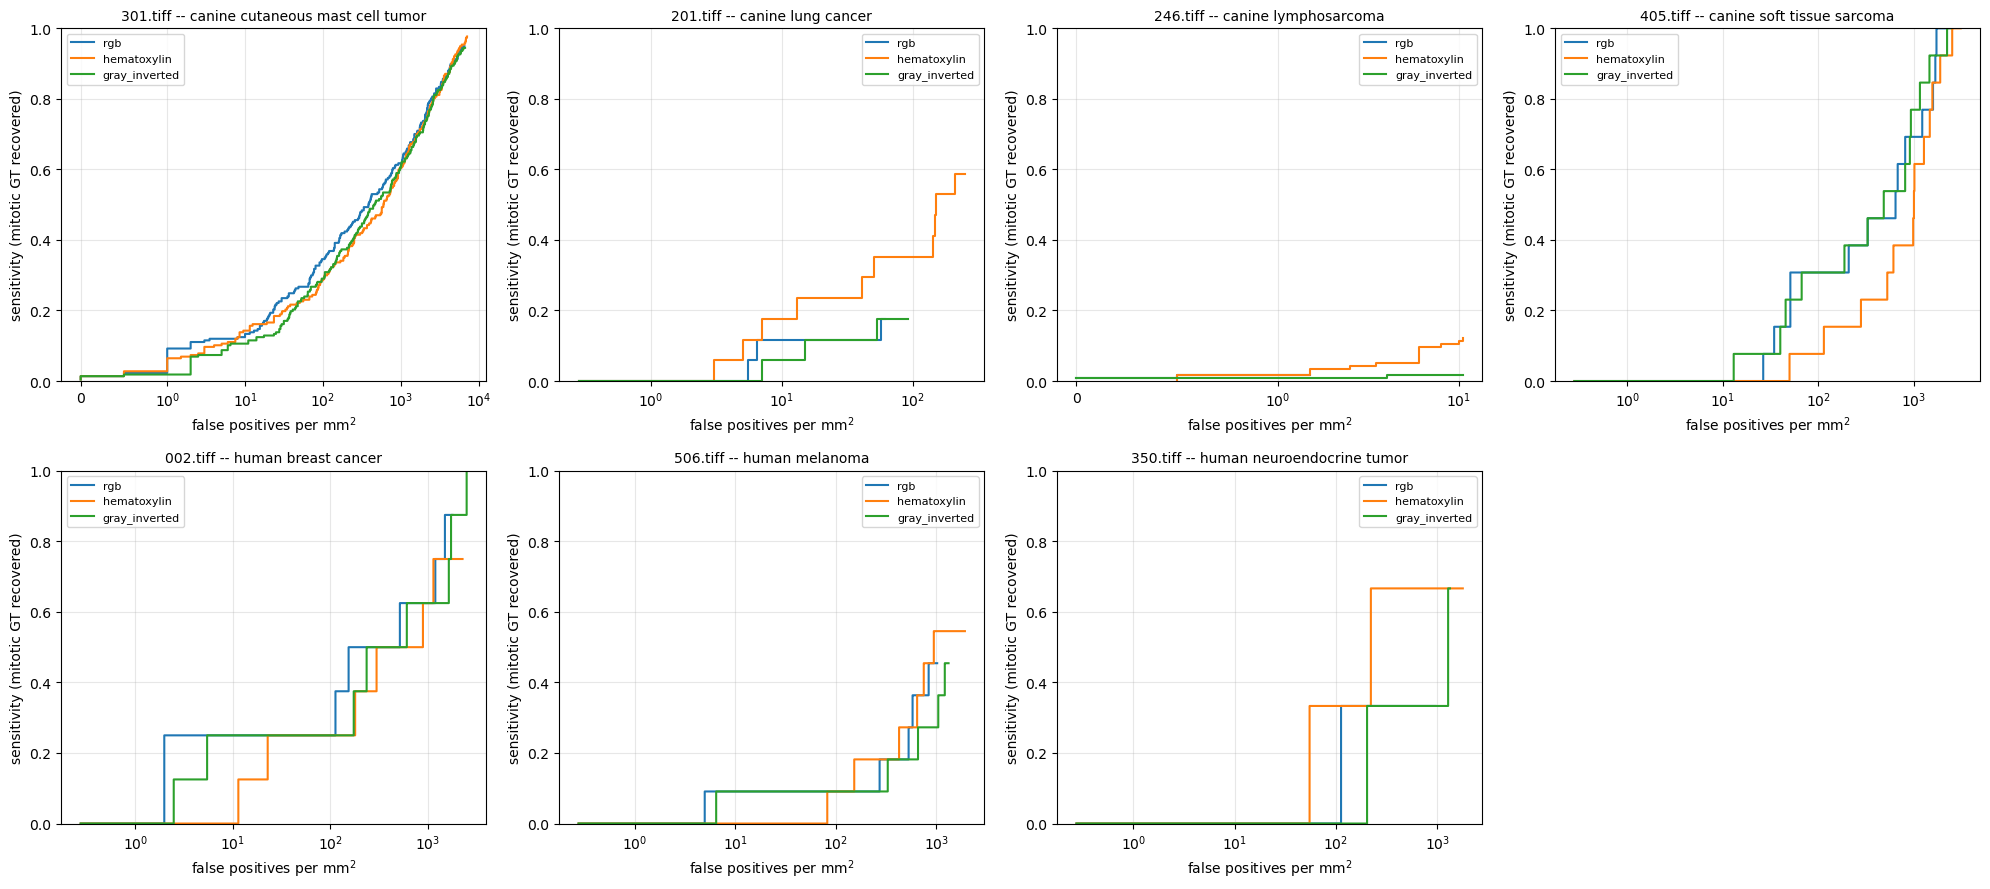

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, fn in zip(axes.ravel(), results.keys()):
    curves = [
        ('rgb', *results[fn]['curve']),
        ('hematoxylin', *results_hem[fn]['curve']),
        ('gray_inverted', *results_gray[fn]['curve']),
    ]
    tumor = selection.loc[selection.file_name == fn, 'tumor_type'].iloc[0]
    viz.froc_plot(curves, ax=ax, title=f'{fn} -- {tumor}')
for ax in axes.ravel()[len(results):]:
    ax.axis('off')
fig.tight_layout(); plt.show()

## Full-list recall ("any annotation hit at all") by channel

Dropping the top-K budget and asking instead: over the *entire* detection list each
channel produced, what fraction of mitotic GT did it eventually hit? This is
`evaluate.lookalike_attraction_rate`'s unbudgeted form (`mitotic_recall`, already computed
in `combined` above -- no re-run needed) rather than `recall_at_k`.

In [17]:
fulllist_pivot = combined.pivot_table(
    index=['tumor_type', 'file_name'], columns='channel',
    values=['mitotic_recall', 'coverage_frac', 'n_detections_total']
).round(3)
fulllist_pivot = fulllist_pivot.reindex(columns=['gray_inverted', 'hematoxylin', 'rgb'], level=1)
fulllist_pivot

coverage_frac                    mitotic_recall                    n_detections_total                     
channel                                    gray_inverted hematoxylin    rgb  gray_inverted hematoxylin    rgb      gray_inverted hematoxylin      rgb
tumor_type                       file_name                                                                                                           
canine cutaneous mast cell tumor 301.tiff          0.847       0.873  0.836          0.945       0.977  0.949            13615.0     14428.0  13353.0
canine lung cancer               201.tiff          0.016       0.045  0.011          0.176       0.588  0.176              188.0       513.0    127.0
canine lymphosarcoma             246.tiff          0.002       0.003  0.000          0.017       0.122  0.017               23.0        35.0      5.0
canine soft tissue sarcoma       405.tiff          0.403       0.498  0.372          1.000       1.000  1.000             4881.0      6224.0   4479.0
human breast cancer              002.tiff          0.395       0.360  0.289          1.000       0.750  0.875             5109.0      4592.0   3621.0
human melanoma                   506.tiff          0.216       0.303  0.168          0.455       0.545  0.455             2682.0      3901.0   2067.0
human neuroendocrine tumor       350.tiff          0.219       0.288  0.160          0.667       0.667  0.333             2700.0      3615.0   1940.0

**Read `coverage_frac` and `n_detections_total` in the same table before trusting
`mitotic_recall`'s ranking -- this is exactly the caveat `evaluate.py`'s module docstring
opens with, and it bites here.** `score_threshold=0.5` is the same fixed cutoff for all
three channels, but `TM_CCOEFF_NORMED`'s score distribution is not the same distribution
for a raw-RGB template as for a single-channel one -- so "how many peaks clear 0.5"
differs by channel for reasons that have nothing to do with mitosis-specificity.
Concretely: hematoxylin returns the *longest* detection list in 6/7 images here (up to
4x rgb's on 201.tiff/246.tiff), and wins on `mitotic_recall` in the same 5 of those
6 -- coverage rising with list length, not necessarily discrimination rising with it. And
405.tiff reads 1.000 for all three channels here, same as it did for the *first* notebook's
24-augmentation run at a lower threshold -- a ceiling this domain's GT density already
saturates at these list lengths, telling us nothing about the channel choice on that row.

**So: on this number alone, no.** Whichever channel happens to clear the fixed score
floor most often looks like the "winner" here, and that is a property of the threshold,
not demonstrated to be a property of the channel's mitosis signal. The check below
removes the threshold instead of trusting a number it confounds.

### Threshold-free check: does one channel actually discriminate mitosis better?

Same tool the first notebook used to settle *its* fusion-rule question
(`experiment.fusion_variants`) and this notebook's augmentation-footprint doc entry
(`experiment.augmentation_variants`) -- both thin wrappers around `experiment._probe_variants`,
applied here to the channel axis instead of scale or rotation count. It reads the fused
correlation value directly at every annotated location, every detected-nucleus centroid, and
3000 random tissue points -- no peaks, no NMS, no score floor -- so a channel that merely
clears 0.5 more often cannot look like a winner here the way it can above.

Same seed per image as every other section (pulled from `metrics`, not redrawn), so this
is the same seven annotations, just scored without a threshold in the loop.

In [18]:
channel_variants = [
    ('rgb', fs.FSConfig(channel='rgb')),
    ('hematoxylin', fs.FSConfig(channel='hematoxylin')),
    ('gray_inverted', fs.FSConfig(channel='gray_inverted')),
]

t0 = time.time()
probe_rows = []
for _, row in selection.iterrows():
    fn = row['file_name']
    seed_id = int(metrics.loc[(metrics.file_name == fn) &
                              (metrics.method == 'find_and_suppress'), 'seed_ann_id'].iloc[0])
    probe_rows.extend(ex._probe_variants(fn, annotations, seed_id, channel_variants))
    print(f'{fn} done ({time.time()-t0:.0f}s elapsed)', flush=True)

channel_probe = pd.DataFrame(probe_rows)
channel_probe.to_csv('results/fs_simple_channel_probe.csv', index=False)
print(f'\ntotal {time.time()-t0:.0f}s')

301.tiff done (43s elapsed)


201.tiff done (102s elapsed)


246.tiff done (141s elapsed)


405.tiff done (169s elapsed)


002.tiff done (217s elapsed)


506.tiff done (273s elapsed)


350.tiff done (306s elapsed)



total 306s


In [19]:
probe_pivot = channel_probe.merge(
    selection[['file_name', 'tumor_type']], on='file_name'
).pivot_table(
    index=['tumor_type', 'file_name'], columns='variant',
    values=['auc_mitosis_vs_nucleus', 'discrimination', 'median_mitosis_rank']
).round(3)
probe_pivot = probe_pivot.reindex(columns=['gray_inverted', 'hematoxylin', 'rgb'], level=1)
probe_pivot

auc_mitosis_vs_nucleus                    discrimination                    median_mitosis_rank                    
variant                                             gray_inverted hematoxylin    rgb  gray_inverted hematoxylin    rgb       gray_inverted hematoxylin     rgb
tumor_type                       file_name                                                                                                                    
canine cutaneous mast cell tumor 301.tiff                   0.735       0.762  0.743          0.148       0.070  0.140              1788.0       723.0  1753.0
canine lung cancer               201.tiff                   0.805       0.861  0.827         -0.032      -0.038 -0.034               866.0       175.0   392.0
canine lymphosarcoma             246.tiff                   0.761       0.843  0.797          0.093       0.058  0.096              2072.0       595.0  1488.0
canine soft tissue sarcoma       405.tiff                   0.719       0.592  0.702          0.002      -0.167 -0.032              1419.0      2593.0  1114.0
human breast cancer              002.tiff                   0.914       0.895  0.923          0.044       0.043  0.045               217.0       315.0   200.0
human melanoma                   506.tiff                   0.744       0.748  0.773          0.076       0.088  0.092              2496.0      2556.0  2396.0
human neuroendocrine tumor       350.tiff                   0.738       0.859  0.796          0.034       0.172  0.080              1747.0       823.0  1390.0

`auc_mitosis_vs_nucleus` = P(a random mitotic figure outscores a random ordinary
nucleus) under that channel's raw fused response, 0.5 = no signal. `discrimination` =
that AUC minus the look-alike-vs-nucleus AUC -- the part of the signal that is actually
mitosis-specific rather than just "dark compact chromatin", which is the number the whole
experiment's central claim turns on (see the first notebook's *Why so few true
positives* section). `median_mitosis_rank` is where the typical mitotic figure lands
among *all* ordinary nuclei in the ROI -- compare it against `K` (the mitotic count) in
the table two cells up.

Whichever channel wins each row on `auc_mitosis_vs_nucleus`, count it and compare against
the full-list-recall "winner" for the same row above -- if they disagree on a majority of
rows, that is direct evidence the full-list number was tracking list length rather than
signal quality.

In [20]:
auc_cols = [c for c in probe_pivot.columns if c[0] == 'auc_mitosis_vs_nucleus']
auc_winner = probe_pivot[auc_cols].idxmax(axis=1).apply(lambda t: t[1])
recall_winner = fulllist_pivot['mitotic_recall'].idxmax(axis=1)
agree = pd.DataFrame({'auc_winner': auc_winner, 'fulllist_recall_winner': recall_winner})
agree['agrees'] = agree.auc_winner == agree.fulllist_recall_winner
agree

,,auc_winner,fulllist_recall_winner,agrees
tumor_type,file_name,,,
canine cutaneous mast cell tumor,301.tiff,hematoxylin,hematoxylin,True
canine lung cancer,201.tiff,hematoxylin,hematoxylin,True
canine lymphosarcoma,246.tiff,hematoxylin,hematoxylin,True
canine soft tissue sarcoma,405.tiff,gray_inverted,gray_inverted,True
human breast cancer,002.tiff,rgb,gray_inverted,False
human melanoma,506.tiff,rgb,hematoxylin,False
human neuroendocrine tumor,350.tiff,hematoxylin,gray_inverted,False
